<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Final%20UKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [736]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

import copy

In [737]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [738]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Dynamics and measurement functions

In [739]:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_svir').h

In [740]:
#f = tb_simulations.F().f
h = h_a

In [741]:
Lambda = 9.04e-5    # Recruitment rate per day
mu = 4.3e-5         # Mortality rate per day
beta = 0.05     # Removal rate per day
N = 223000000

In [742]:
def f(x_vec, u_vec, Lambda=Lambda, mu=mu, beta=beta, return_state_names=False):
        """
        Continuous time dynamics function for TB SVIR model.

        Parameters:
        x_vec : array-like, shape (6,)
            State vector [S, V, I, R, beta, sigma]
        u_vec : array-like, shape (2,)
            Control vector [alpha, kappa]
            alpha: vaccination rate
            kappa: social distancing effectiveness (0=no distancing, 1=full distancing)
        Lambda : float, default 9.04e-5
            Recruitment rate per day
        mu : float, default 4.3e-5
            Mortality rate per day
        gamma : float, default 0.00555
            Removal rate per day

        Returns:
        x_dot : numpy array, shape (6,)
            Time derivative of state vector
        """
        if return_state_names:
            return ['S', 'V', 'I', 'R', 'gamma', 'sigma']

        # Extract state variables
        S = x_vec[0]
        V = x_vec[1]
        I = x_vec[2]
        R = x_vec[3]
        gamma = x_vec[4]
        sigma = x_vec[5]

        # Extract control inputs
        alpha = u_vec[0]  # vaccination rate
        kappa = u_vec[1]  # social distancing effectiveness

        # f0 component: drift dynamics (no controls)
        f0_contribution = np.array([Lambda - beta * S * I - mu * S,
                                     -sigma * V * I - mu * V,
                                     beta*S*I + sigma*V*I - gamma*I - mu*I,
                                     gamma*I - mu*R,
                                     0,
                                     0])

        # f1 component: multiplied by control alpha (vaccination)
        f1_contribution = alpha * np.array([-S,
                                             S,
                                             0,
                                             0,
                                             0,
                                             0])

        # f2 component: multiplied by control kappa (social distancing)
        # Social distancing reduces transmission: effective beta becomes beta*(1-kappa)
        f2_contribution = kappa * np.array([beta*S*I,
                                             sigma*V*I,
                                             -beta*S*I - sigma*V*I,
                                             0,
                                             0,
                                             0])

        # Combined dynamics
        x_dot_vec = f0_contribution + f1_contribution + f2_contribution

        return x_dot_vec


In [743]:
h(None, None, return_measurement_names=True)

['I_absolute', 'V_absolute', 'R_absolute']

In [744]:
def u_func(x_vec, t):
    """Simple vaccination and social distancing controller"""
    I = x_vec[2]
    alpha = 0.01
    kappa = 0.1
    return np.array([alpha, kappa])

In [745]:
def f_ode(x_vec, t):
    """Wrapper for odeint"""
    u_vec = u_func(x_vec, t)
    return f(x_vec, u_vec)

In [746]:
N = 223000000
x0_true = np.array([
    0.8,     # S: 0.6726 (67.26%)
    0.1,      # V: 0.1000 (10.00%)
    0.1794,      # I: 0.1794 (17.94%) - MUCH HIGHER infected population
    0.048,      # R: 0.0480 (4.80%)
    0.00555,         # beta: realistic TB transmission (slow)(0.05)
    0.0001375          # sigma(0.00275)
])

# FILTER INITIAL GUESS
x0_filter = np.array([
    0.654,
    0.23,
    0.5,
    0.1,
    0.001,
    0.004
])

# Run simulation

In [747]:
t_sim = np.arange(0, 60, 1.0)
result = odeint(f_ode, x0_true, t_sim)

In [748]:
x_sim = {
    'S': result[:, 0],
    'V': result[:, 1],
    'I': result[:, 2],
    'R': result[:, 3],
    'gamma': result[:, 4],
    'sigma': result[:, 5]
}

In [749]:
u_sim = {'alpha': [], 'kappa': []}
for i in range(len(t_sim)):
    u = u_func(result[i], t_sim[i])
    u_sim['alpha'].append(u[0])
    u_sim['kappa'].append(u[1])

In [750]:
y_true_absolute = {
    'S_absolute': x_sim['S'] * N,
    'V_absolute': x_sim['V'] * N,
    'I_absolute': x_sim['I'] * N,
    'R_absolute': x_sim['R'] * N,
    'gamma': x_sim['gamma'],
    'sigma': x_sim['sigma']
}

# Simulate noisy measurements

In [751]:
measurement_noise_stds = {
    'S_absolute': 100000.0,
    'I_absolute': 10000.0,
    'V_absolute': 100000.0,
    'R_absolute': 5000.0,
    'gamma': 1e-8,
    'sigma': 1e-8
}

In [752]:
# Add noise
np.random.seed(42)
y_noisy_absolute = {
    key: y_true_absolute[key] + np.random.normal(0, measurement_noise_stds[key], len(t_sim))
    for key in y_true_absolute.keys()
}

In [753]:
y_noisy = {key: y_noisy_absolute[key] / N for key in y_noisy_absolute.keys()}

<Axes: xlabel='Time', ylabel='R_absolute'>

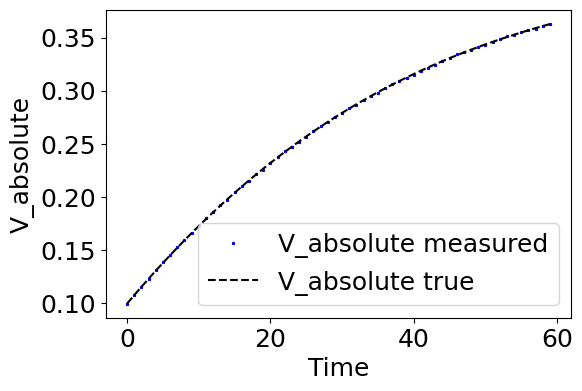

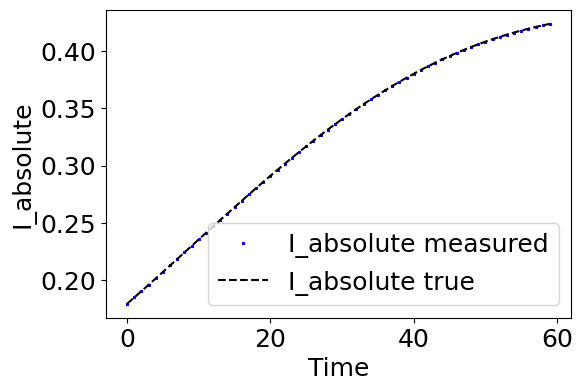

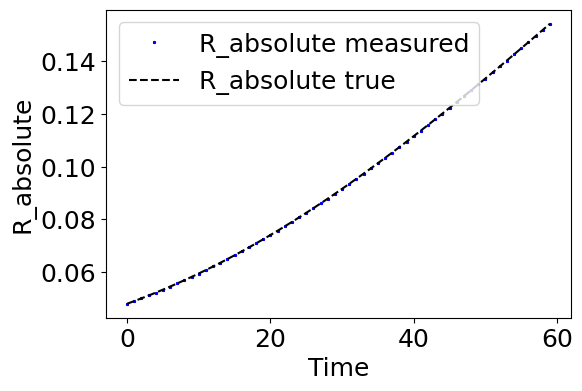

In [754]:
plot_tme(t_sim, x_sim['V'], y_noisy['V_absolute'], label_var='V_absolute')
plot_tme(t_sim, x_sim['I'], y_noisy['I_absolute'], label_var='I_absolute')
plot_tme(t_sim, x_sim['R'], y_noisy['R_absolute'], label_var='R_absolute')

### Save data as dataframes

In [755]:
y_noisy_df = pd.DataFrame({
    'I_absolute': y_noisy['I_absolute'],  # First
    'V_absolute': y_noisy['V_absolute'],  # Second
    'R_absolute': y_noisy['R_absolute']   # Third
})
u_sim_df = pd.DataFrame(u_sim)
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

# Kalman filter parameters and initilization

In [756]:
P0 = np.diag([
    0.01,
    0.01,
    0.002,
    0.02,
    0.00001,
    0.05
])

Q = np.diag([
    1e-6,
    1e-6,
    1e-7,
    1e-6,
    1e-10,
    1e-10
])

R_stds = np.array([
    measurement_noise_stds['I_absolute'] / N,
    measurement_noise_stds['V_absolute'] / N,
    measurement_noise_stds['R_absolute'] / N,
])
R = np.diag(R_stds**2)

# Extended Kalman Filter

In [757]:
EKF = extended_kalman_filter.EKF(
    f, h, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    circular_measurements=(0, 0, 0)
)

In [758]:
EKF.estimate(y_noisy_df, u_sim_df)

In [759]:
EKF.history.keys()

dict_keys(['X', 'U', 'Z', 'P', 'P_diags', 'R', 'Q', 'F', 'H', 'S', 'K', 'E', 'rho', 'Jk', 'inv_Jk'])

In [760]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [761]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

## Plots

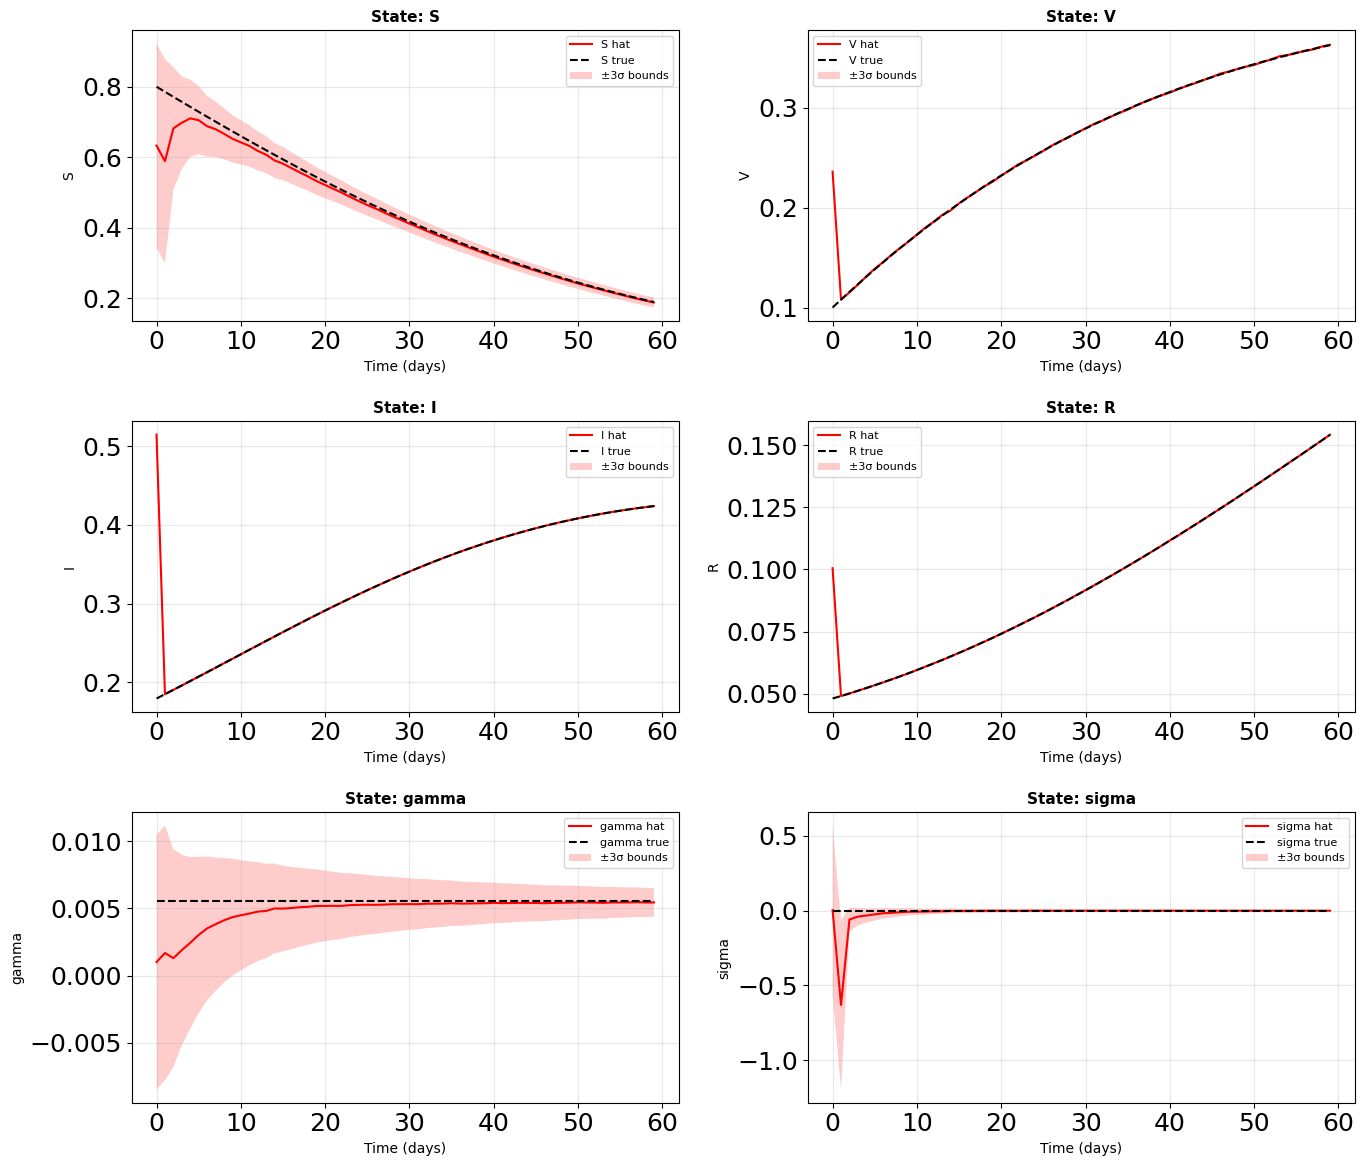

In [762]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # No measurements - only plot true and estimate for all states
    plot_tme(t_sim, x_sim[state], None, x_est_col,
            label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Unscented Kalman Filter

In [763]:
UKF = unscented_kalman_filter.UKF(
    f, h, x0_filter, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=1.0,
    alpha=0.1
)

In [764]:
UKF.estimate(y_noisy_df, u_sim_df)

In [765]:
UKF.history.keys()

dict_keys(['X', 'P', 'P_diags', 'sigma_points'])

In [766]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))

In [767]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

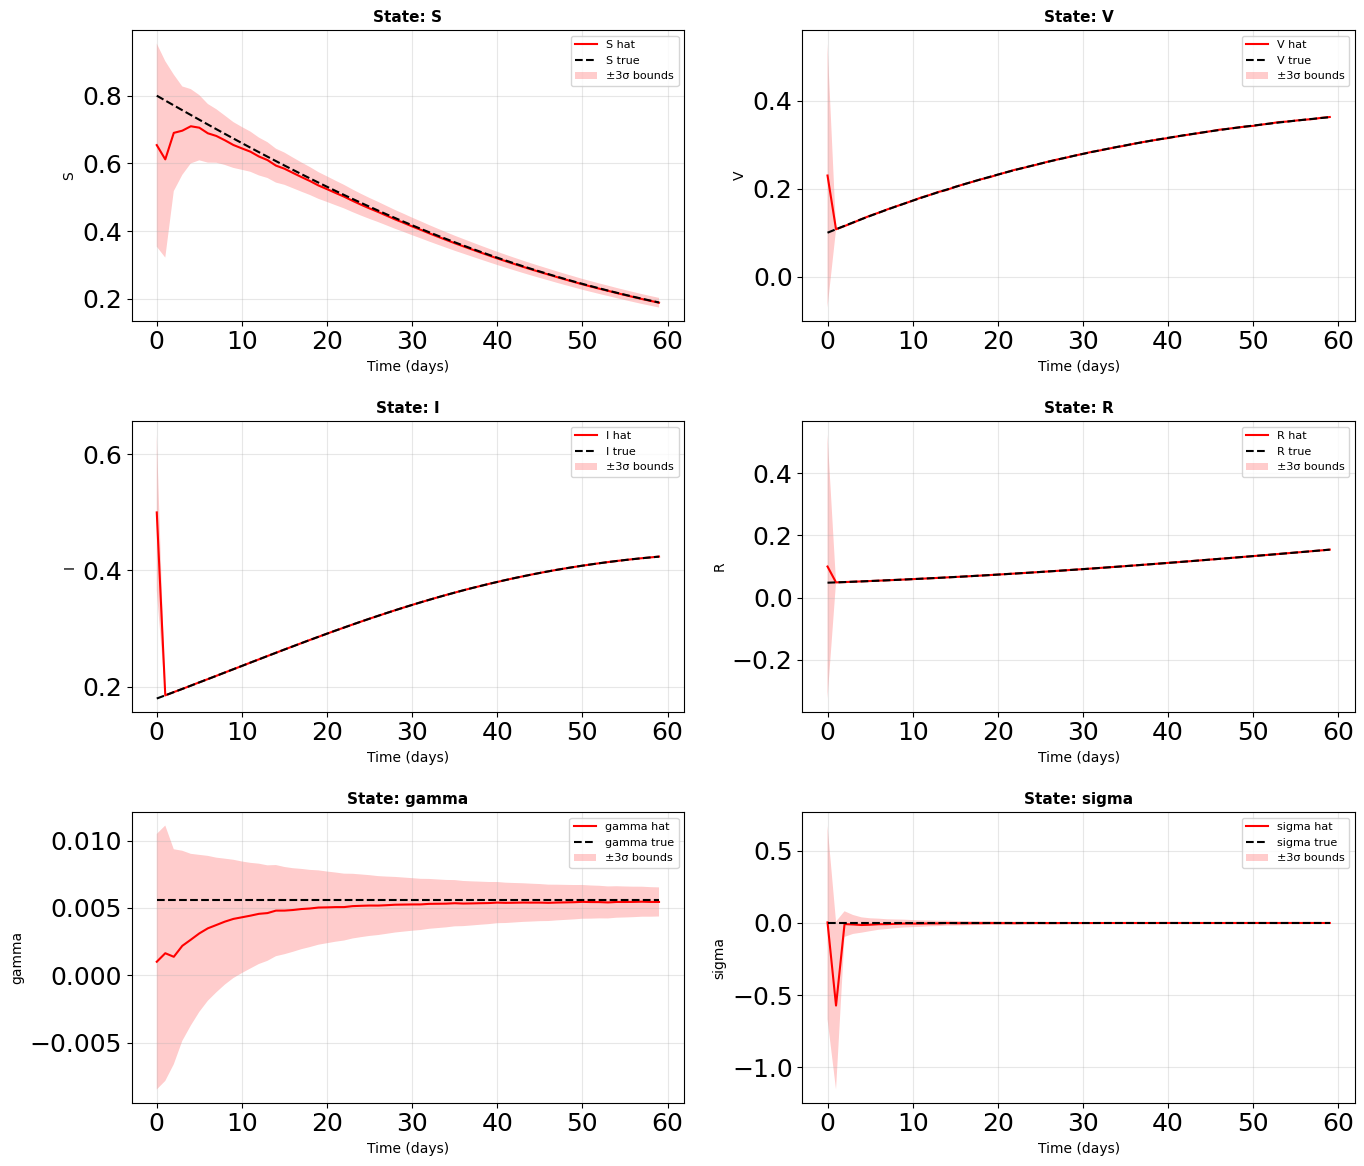

In [768]:
import matplotlib.pyplot as plt
import numpy as np

# Get state names
state_names = f(None, None, return_state_names=True)
n_states = len(state_names)

# Create subplots - 3 rows x 2 columns for 6 states
fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=100)
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Convert to numpy arrays once
x_est_array = np.array(x_est)
P_diags_array = np.array(P_diags)

# Plot each state
for i, state in enumerate(state_names):
    ax = axes[i]

    # Extract columns for this state
    x_est_col = x_est_array[:, i]
    P_diag_col = P_diags_array[:, i]

    # No measurements - only plot true and estimate for all states
    plot_tme(t_sim, x_sim[state], None, x_est_col,
            label_var=state, ax=ax)

    # Add 3-sigma uncertainty bounds
    plus_3sigma = x_est_col + 3*np.sqrt(P_diag_col)
    minus_3sigma = x_est_col - 3*np.sqrt(P_diag_col)
    ax.fill_between(t_sim, plus_3sigma, minus_3sigma,
                    facecolor='red', edgecolor='none', alpha=0.2,
                    label='±3σ bounds')

    # Formatting
    ax.set_xlabel('Time (days)', fontsize=10)
    ax.set_ylabel(f'{state}', fontsize=10)
    ax.set_title(f'State: {state}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()